# Лабораторная работа 2. Спектральные характеристики сигналов.

**Целью работы** является исследование свойств оценок спектра Фурье для широкополосных и узкополосных сигналов, применение спектров для анализа характеристик тональных сигналов.

 <hr>    

<font style="color:#1560BD;" size="5">[Начальные установки](#introduction)</font>

<font style="color:#1560BD;" size="5">[Задание 1. Исследование спектра белого шума](#job1)</font>    

<font style="color:#1560BD;" size="5">[Задание 2. Исследование спектра тонального сигнала](#job2)</font>    

<font style="color:#1560BD;" size="5">[Задание 3. Обнаружение тональных сигналов с близкими частотами](#job3)</font>    

<font style="color:#1560BD;" size="5">[Задание 4. Обнаружение гармоники в шуме](#job4)</font>        

<font style="color:#1560BD;" size="5">[Задание 5. Спектр периодического импульсного сигнала](#job5)</font>

## Начальные установки
<a id="introduction"></a>

In [ ]:
# Импорт библиотек
import matplotlib.pyplot as plt
import numpy as np
import librosa

# Игнорируем предупреждения
from warnings import filterwarnings

filterwarnings("ignore")

In [ ]:
# Проверка версии библиотеки
print(librosa.__version__)

0.11.0


In [ ]:
# Конфигурируем директорию данных
Speech_dir = "/home/artyom/myprojects/ITMO/AEA/mors/speech"  # Сигналы для второй лабораторной работы

<div class="alert alert-block alert-info">

## Задание 1. Исследование спектра белого шума
<a id="job1"></a>
* Возьмите сигнал **White_noise_11025** (белый шум).

* Постройте средний спектр с разными размерами окон.

* Как влияет размер окна на оценку среднего спектра?

* Как влияет длительности выборки на оценку среднего спектра?

* Увеличьте (уменьшите) амплитуду сигнала в 2 раза. Как изменится спектр (в линейном и логарифмическом масштабе дБ)?
</div>

In [ ]:
# Загружаем сигнал  White_noise_11025.wav
data_White_noise_11025, sr_White_noise_11025 = librosa.load(
    Speech_dir + "//White_noise_11025.wav", sr=None
)

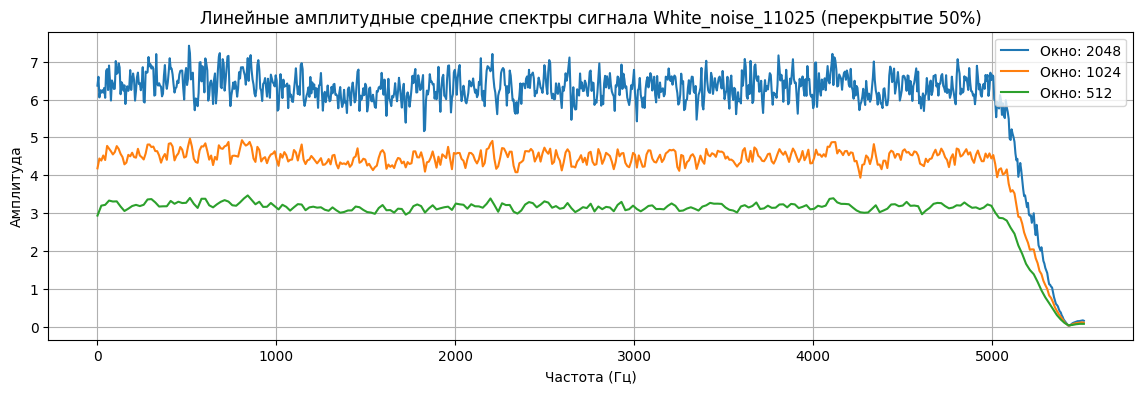

In [ ]:
# Строим средние амплитудные спектры с разными размерами окон (перекрытие 50%)
n_fft = [2048, 1024, 512]

plt.figure(figsize=(14, 4))
plt.title(
    "Линейные амплитудные средние спектры сигнала White_noise_11025 (перекрытие 50%)"
)
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")

for i in range(3):
    S = np.abs(
        librosa.stft(data_White_noise_11025, n_fft=n_fft[i], hop_length=n_fft[i] // 2)
    )
    S_AVG = np.mean(S, axis=1)

    # Частоты
    freqs = librosa.fft_frequencies(sr=sr_White_noise_11025, n_fft=n_fft[i])
    plt.plot(freqs, S_AVG, label="Окно: {:d}".format(n_fft[i]))

plt.legend(loc=1)
plt.grid(True)
plt.show()

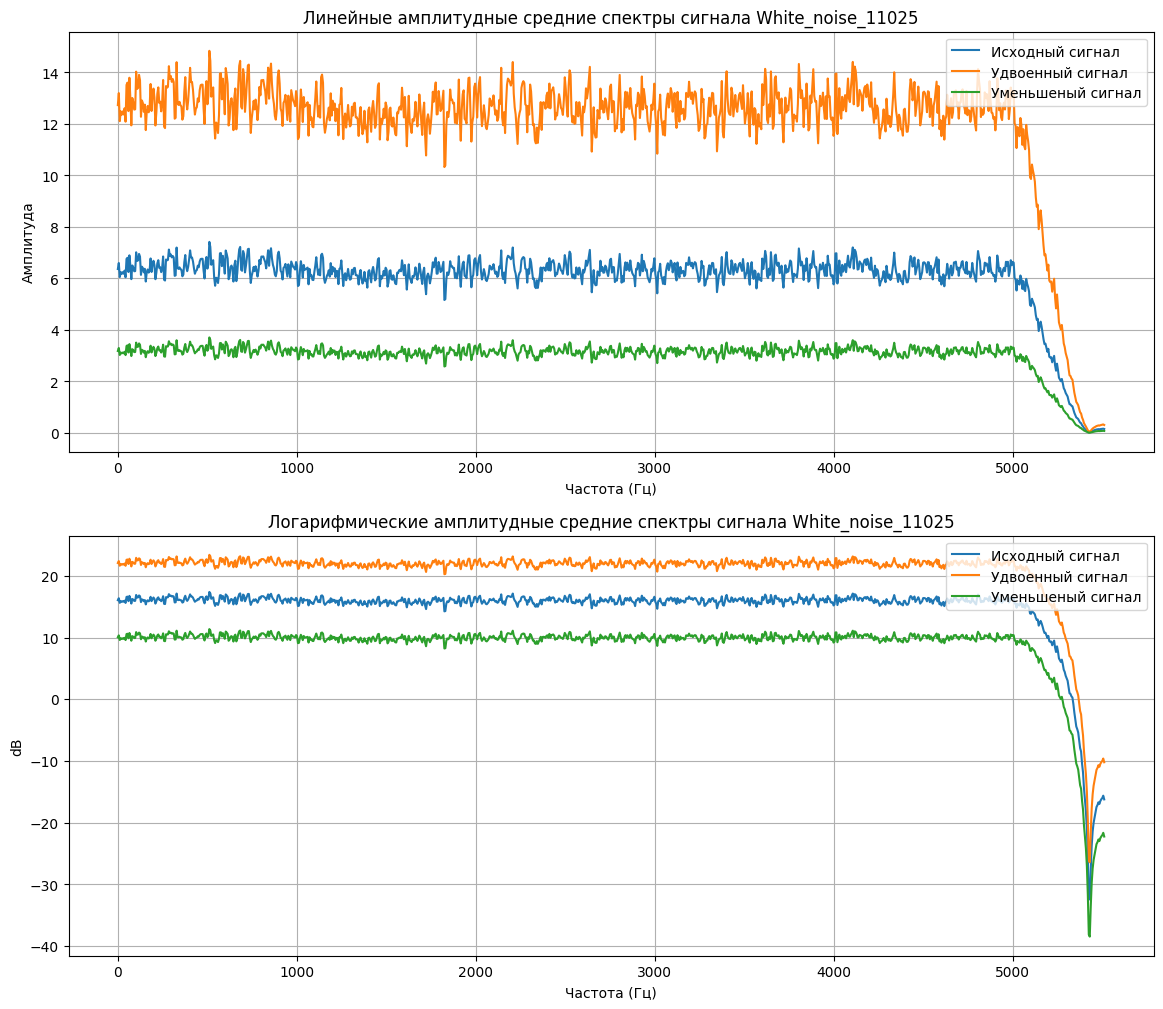

In [ ]:
# Изменяем амплитуду сигнала
data_White_noise_11025_2 = data_White_noise_11025 * 2
data_White_noise_11025_05 = data_White_noise_11025 / 2

n_fft = 2048
freqs = librosa.fft_frequencies(sr=sr_White_noise_11025, n_fft=n_fft)

labels = ["Исходный сигнал", "Удвоенный сигнал", "Уменьшеный сигнал"]
lst_sig = [data_White_noise_11025, data_White_noise_11025_2, data_White_noise_11025_05]

# Строим средние амплитудные спектры (перекрытие 50%)
fig, ax = plt.subplots(2, 1, figsize=(14, 12))
ax[0].set(
    title="Линейные амплитудные средние спектры сигнала White_noise_11025",
    ylabel="Амплитуда",
    xlabel="Частота (Гц)",
)
ax[1].set(
    title="Логарифмические амплитудные средние спектры сигнала White_noise_11025",
    ylabel="dB",
    xlabel="Частота (Гц)",
)

for i in range(3):
    S = np.abs(librosa.stft(lst_sig[i], n_fft=n_fft, hop_length=n_fft // 2))
    S_AVG = np.mean(S, axis=1)
    ax[0].plot(freqs, S_AVG, label=labels[i])

    S_AVG_DB = librosa.amplitude_to_db(S_AVG)
    ax[1].plot(freqs, S_AVG_DB, label=labels[i])

ax[0].legend(loc=1)
ax[0].grid(True)
ax[1].legend(loc=1)
ax[1].grid(True)

<div class="alert alert-block alert-success">
<b>Ответ на задание 1:</b>
<a id="answer-job1"></a>

При меньшем размере окна значения амплитуды меньше. Поскольку после примения Быстрого Преобразования Фурье мы получаем произведение отсчётов и больше окно - больше отсчётов, то мы получаем больше значение апмлитуды спектра.

Также при меньшем размере окна видно меньше коллебаний, так как меньше частотное разрешение. Благодаря этому мы в целом видим больше значений на графике.

В случае линейного графика мы видим линейно отличие по амплитудам и где-то по 6 ($\approx 20 * log_{10} (2)$) дБ в логарифмическом.


</div>

<div class="alert alert-block alert-info">

## Задание 2. Исследование спектра тонального сигнала
<a id="job2"></a>

* Сгенерируйте тональный сигнал с частотой дискретизации 11025Гц, длительность 15 с, периодом 10 отсчетов (1102 Гц).

* Постройте мгновенные спектры на разных участках сигнала.

* Постройте средний спектр.

* Исследуйте роль размера окна (как зависит оценка среднего спектра от размера окна?)

* Исследуйте роль весовой функции окна (чем различаются средние спектры для разных типов весовых функций?)
</div>

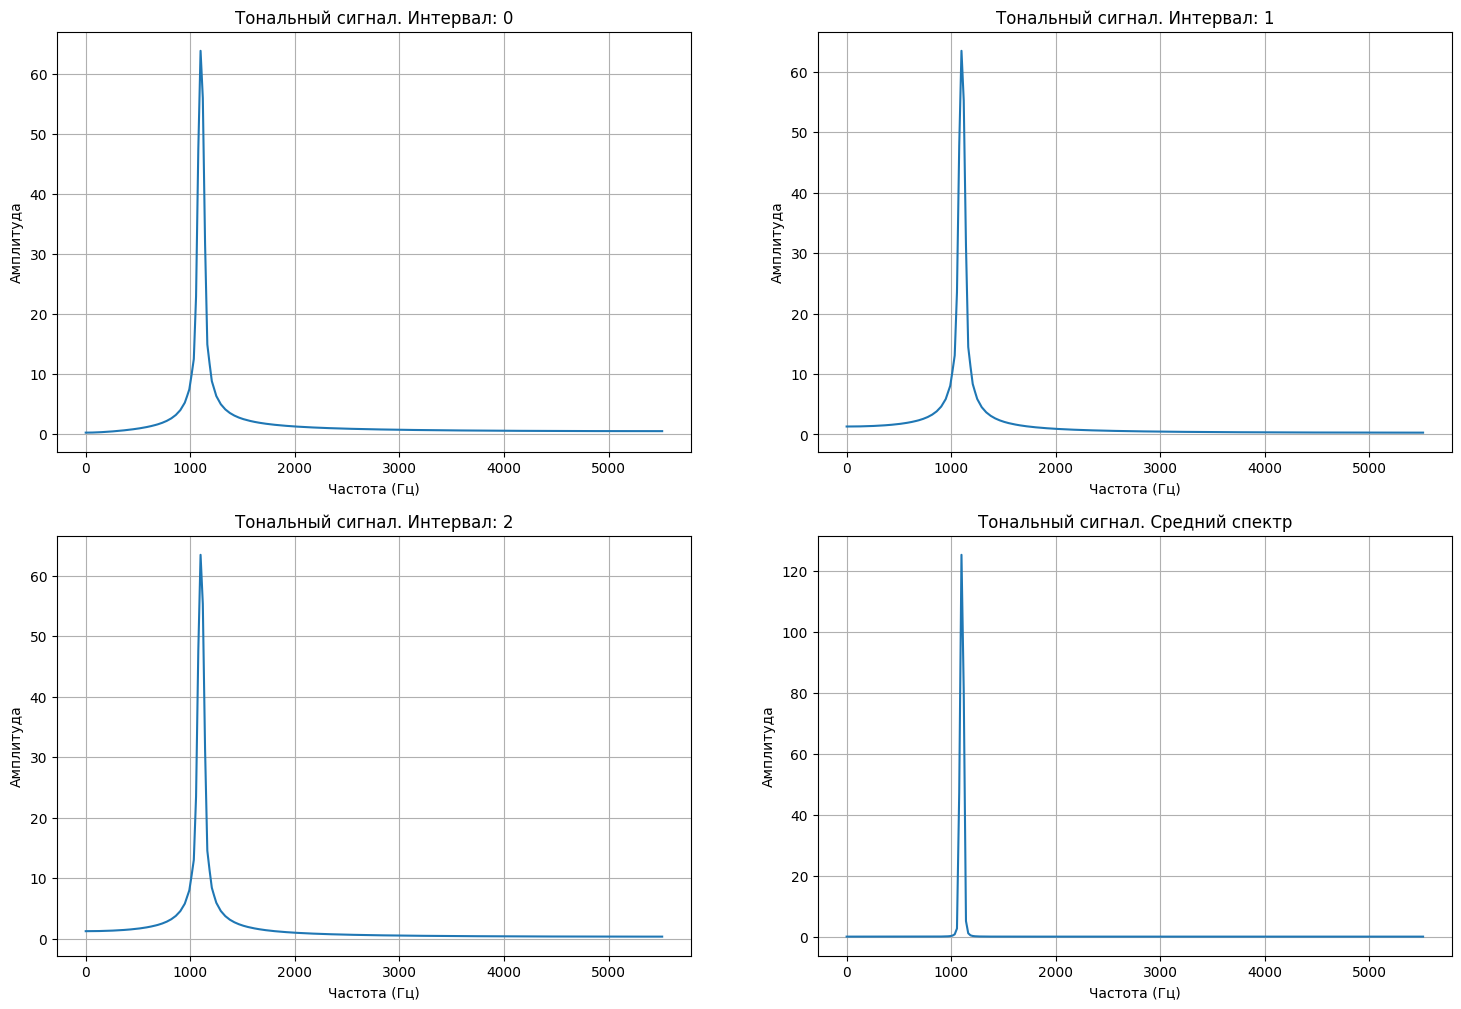

In [ ]:
# Генерация тонального сигнала: основная частота, длительность(сек.), частота дискретизации (гц)
tone = librosa.tone(1102, duration=15, sr=11025)

# Строим мгновенные спектры на разных участках сигнала
n_fft = 512
freqs = librosa.fft_frequencies(sr=11025, n_fft=n_fft)

start = [5000, 12100, 23400]
plt.figure(figsize=(18, 12))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    if i < 3:
        sp_tone = np.abs(
            librosa.stft(
                tone[start[i] : start[i] + n_fft], n_fft=n_fft, hop_length=n_fft + 1
            )
        )
        plt.title("Тональный сигнал. Интервал: {:d}".format(i))
    else:
        toneMean = np.abs(librosa.stft(tone, n_fft=n_fft, hop_length=n_fft // 2))
        sp_tone = np.mean(toneMean, axis=1)
        plt.title("Тональный сигнал. Средний спектр")

    plt.plot(freqs, sp_tone)
    plt.xlabel("Частота (Гц)")
    plt.ylabel("Амплитуда")
    plt.grid(True)

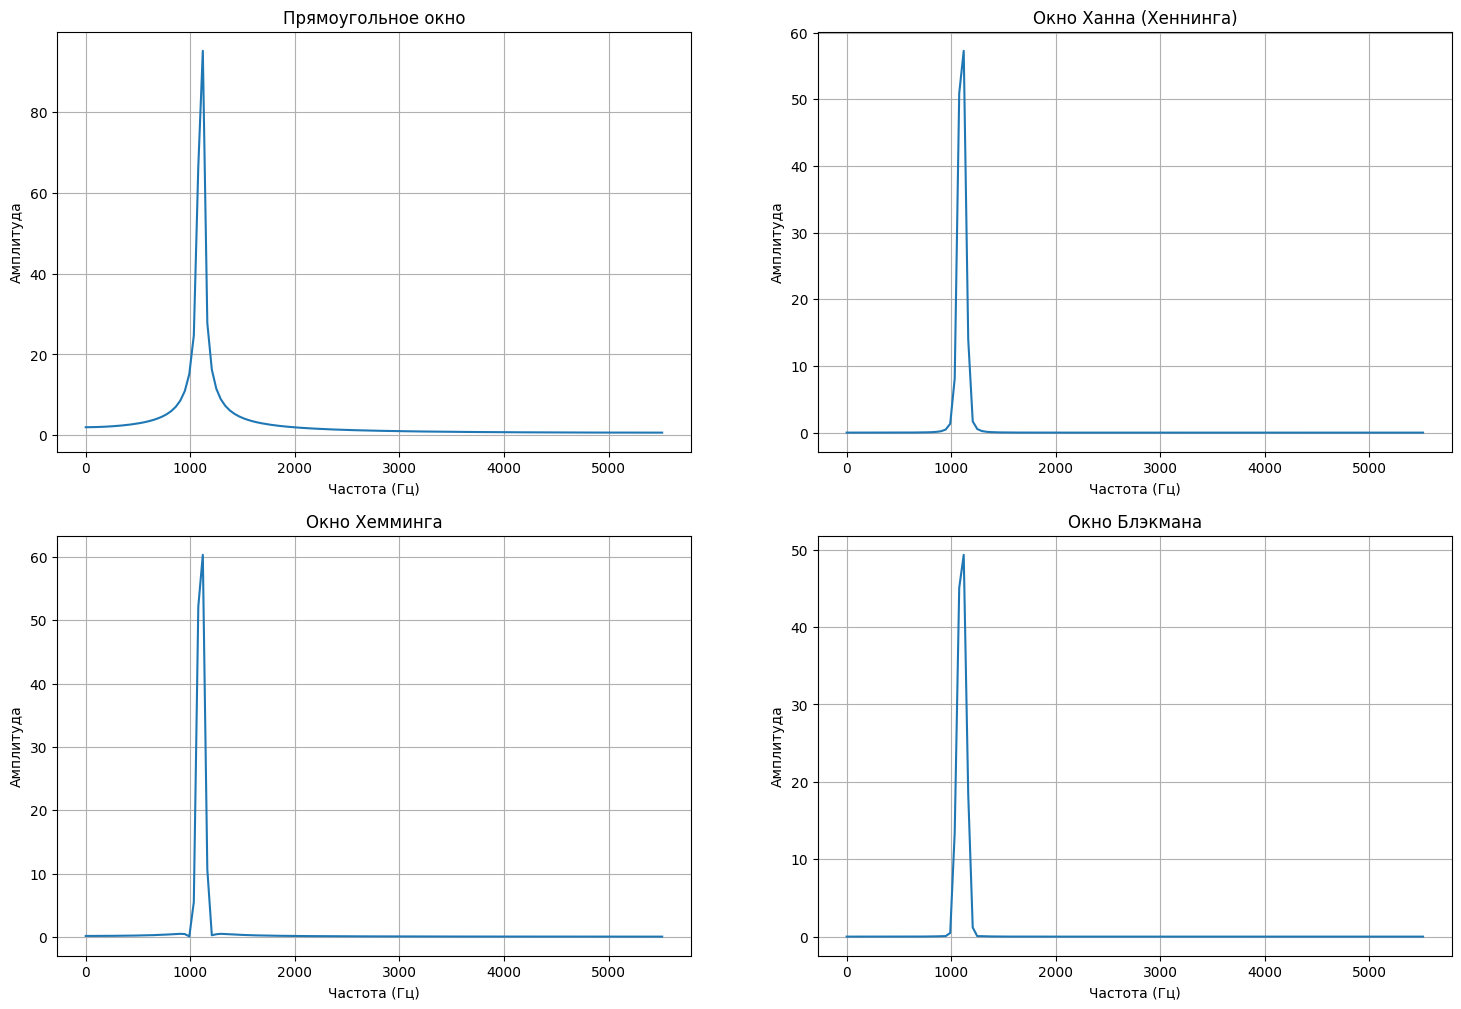

In [ ]:
# Средний спектр для различных весовых функций
n_fft = 256
freqs = librosa.fft_frequencies(sr=11025, n_fft=n_fft)

w_boxcar = librosa.filters.get_window("boxcar", n_fft)  # Прямоугольное окно
w_hann = librosa.filters.get_window("hann", n_fft)  # Окно Ханна (Хеннинга)
w_hamming = librosa.filters.get_window("hamming", n_fft)  # Окно Хемминга
w_blackman = librosa.filters.get_window("blackman", n_fft)  # Окно Блэкмана

labels = [
    "Прямоугольное окно",
    "Окно Ханна (Хеннинга)",
    "Окно Хемминга",
    "Окно Блэкмана",
]
lst_win = [w_boxcar, w_hann, w_hamming, w_blackman]

plt.figure(figsize=(18, 12))

for i in range(4):
    plt.subplot(2, 2, i + 1)

    tone_win = np.abs(
        librosa.stft(tone, n_fft=n_fft, hop_length=n_fft // 2, window=lst_win[i])
    )
    tone_win_AVG = np.mean(tone_win, axis=1)

    plt.plot(freqs, tone_win_AVG)
    plt.title(labels[i])
    plt.xlabel("Частота (Гц)")
    plt.ylabel("Амплитуда")
    plt.grid(True)

<div class="alert alert-block alert-success">
<b>Ответ на задание 2:</b>
<a id="answer-job2"></a>

Окна с интервалами 0, 1 и 2 имеют одинаковый размер окна и визуально никак не отличаются. В случае же со средним спектром мы взяли в два раза меньше шаг окна, из-за чего значение амплитуды пропорционально выросло

Окна располагаются по убыванию амплитуды у пика. По ширине пика Прямоугольное > Блэкмана > Ханна > Хэмминга, где ширина отвечает за утечку главного спектра.
</div>

<div class="alert alert-block alert-info">

## Задание 3. Обнаружение тональных сигналов с близкими частотами
<a id="job3"></a>

* Возьмите сигнал с близкими частотами (40sin1_sin2.wav)

* Постройте средний спектр.

* Исследуйте влияние размера окна на частотное разрешение.

* При каком размере окна можно различить гармоники?

* Исследуйте влияние типа окна (прямоугольное, Хэмминга, Гаусса) на частотное разрешение.
</div>

In [ ]:
# Загружаем сигнал 40_sin1_sin2.wav
data_40_sin1_sin2, sr_40_sin1_sin2 = librosa.load(
    Speech_dir + "//40_sin1_sin2.wav", sr=None
)

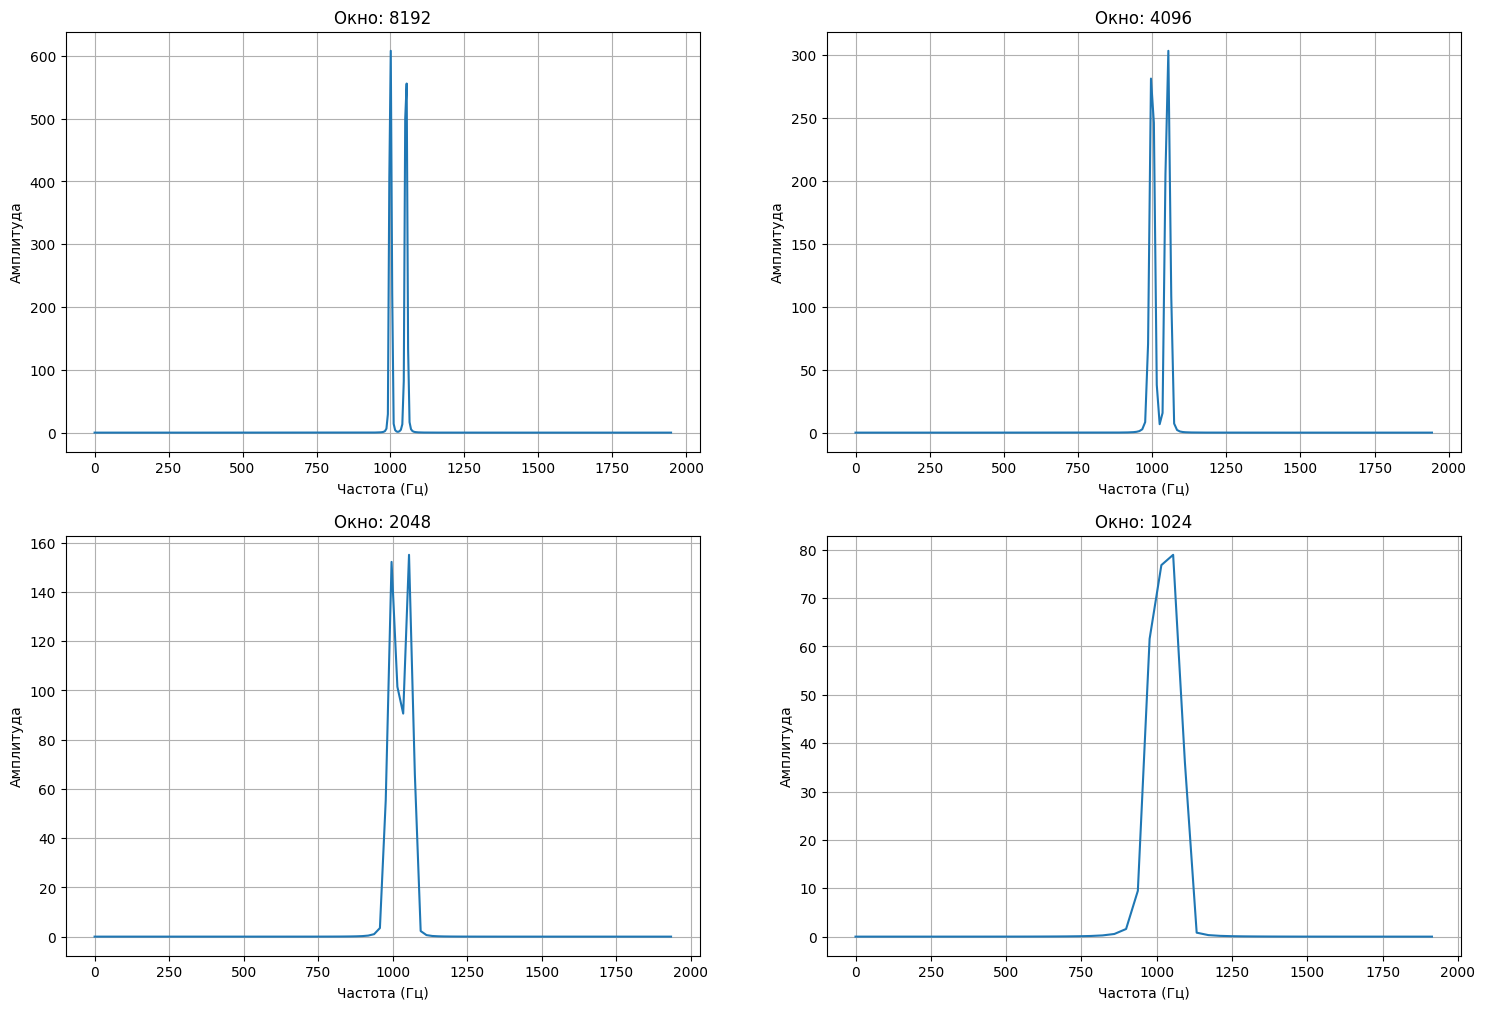

In [ ]:
# Строим средние амплитудные спектры с разными размерами окон (перекрытие 50%)
fft_size = [8192, 4096, 2048, 1024]
sig_size = [400, 200, 100, 50]

plt.figure(figsize=(18, 12))

for i in range(4):
    plt.subplot(2, 2, i + 1)

    Sp = np.abs(
        librosa.stft(data_40_sin1_sin2, n_fft=fft_size[i], hop_length=fft_size[i] // 2)
    )
    Sp_AVG = np.mean(Sp, axis=1)

    # Частоты
    freqs = librosa.fft_frequencies(sr=sr_40_sin1_sin2, n_fft=fft_size[i])

    plt.plot(freqs[0 : sig_size[i]], Sp_AVG[0 : sig_size[i]])
    plt.title("Окно: {:d}".format(fft_size[i]))
    plt.xlabel("Частота (Гц)")
    plt.ylabel("Амплитуда")
    plt.grid(True)

<div class="alert alert-block alert-success">
<b>Ответ на задание 3:</b>
<a id="answer-job3"></a>

Меньше окно - меньше частотное разрешение. Гармоники хорошо различимы на частоте 8192, в целом различимы, но с утечной на переходе между гармониками при частоте 4096, также различимы, но с ещё большей спектральной утечкой на частоте 2048 и неразличимы при окне 1024

Судя по 2 заданию - у окна Хэмминга лучше подавление краёв лепестка, у прямоугольного - выше разрешение возле гармоники (на пике графика).
</div>

<div class="alert alert-block alert-info">

## Задание 4. Обнаружение гармоники в шуме
<a id="job4"></a>
* Сгенерируйте тональный сигнал (с различными амплитудами) в белом шуме (максимальное значение амплитуды шумового сигнала ≈ 4 СКО)

* Можно ли обнаружить тональный сигнал в среднем спектре?

* Исследовать зависимость обнаружения слабой гармоники от размера окна ($256-512-1024-2048$).

* Объясните полученный результат.
</div>

In [ ]:
# Генерация белого шума
def WhiteNoiseGen(sample_rate, mean, std, duration, amp):
    # sample_rate - частота (в гц)
    # mean - среднее значение нормального распределения
    # std - стандартное отклонение распределения
    # duration - длительность (в секундах)
    noise = amp * np.random.normal(0, 1, sample_rate * duration)
    return noise

noise rms = 3.998946635180461 , noise max = 17.761554965184192 , noise min = -17.59001947601832
tone rms = 0.14142135623730953 , tone max = 0.19999873129072274 , tone min = -0.1999987312907275


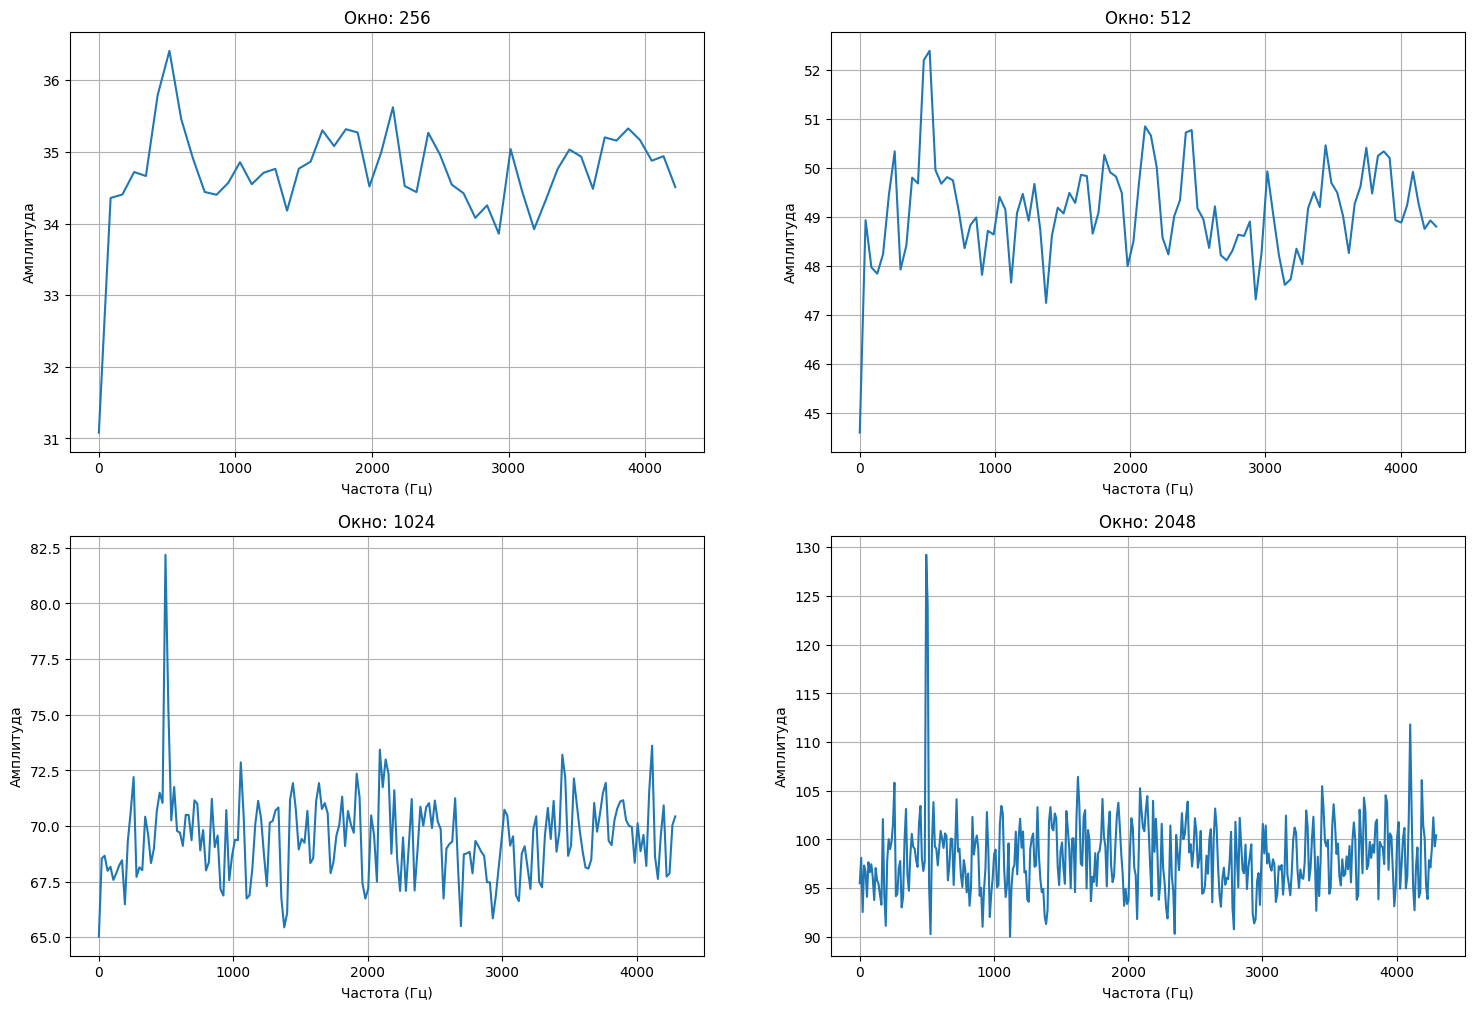

In [ ]:
# Генерация белого шума
noiseAmplitude = 4
white_noise = WhiteNoiseGen(
    sample_rate=22050, mean=0, std=1, duration=10, amp=noiseAmplitude
)

print(
    "noise rms =",
    np.std(white_noise),
    ", noise max =",
    max(white_noise),
    ", noise min =",
    min(white_noise),
)

# Генерация тонального сигнала: основная частота, длительность(сек.), частота дискретизации (гц)
toneAmplitude2 = 0.20
tone440 = toneAmplitude2 * librosa.tone(500, duration=10, sr=22050)

print(
    "tone rms =",
    np.std(tone440),
    ", tone max =",
    max(tone440),
    ", tone min =",
    min(tone440),
)

# Добавляем белый шум к тональному сигналу
mixed2 = tone440 + white_noise

# Строим средние амплитудные спектры с разными размерами окон (перекрытие 50%)
fft_size = [256, 512, 1024, 2048]
sig_size = [50, 100, 200, 400]

plt.figure(figsize=(18, 12))

for i in range(4):
    plt.subplot(2, 2, i + 1)

    Sp = np.abs(librosa.stft(mixed2, n_fft=fft_size[i], hop_length=fft_size[i] // 2))
    Sp_AVG = np.mean(Sp, axis=1)

    # Частоты
    freqs = librosa.fft_frequencies(sr=22050, n_fft=fft_size[i])

    plt.plot(freqs[0 : sig_size[i]], Sp_AVG[0 : sig_size[i]])
    plt.title("Окно: {:d}".format(fft_size[i]))
    plt.xlabel("Частота (Гц)")
    plt.ylabel("Амплитуда")
    plt.grid(True)

<div class="alert alert-block alert-success">
<b>Ответ на задание 4:</b>
<a id="answer-job4"></a>

Да, можно. Где-то около 500 Гц самый большой пик. Но с окном 256 труднее

С большим окном лучше видны отдельные пики, а значит проще обнаружить слабую гармонику.

При увеличении длины окна N, амплитуда пика в спектре растет пропорционально за счёт большего числа банков
</div>

<div class="alert alert-block alert-info">

## Задание 5. Спектр периодического импульсного сигнала
<a id="job5"></a>
* Возьмите сигнал **11_100Hz.wav**

* Определите по осциллограмме период (частоту импульсов) импульсного сигнала. 

* Исследуйте зависимость среднего спектра от размера окна (256-512-1024-2048).

* Сравните длину окон с периодом импульсного сигнала.

* При какой длине окна в спектре периодического импульсного сигнала проявляется его тональная структура?
</div>

In [ ]:
# Загружаем сигнал 11_100Hz.wav
data_11_100Hz, sr_11_100Hz = librosa.load(Speech_dir + "//11_100HZ.WAV", sr=None)

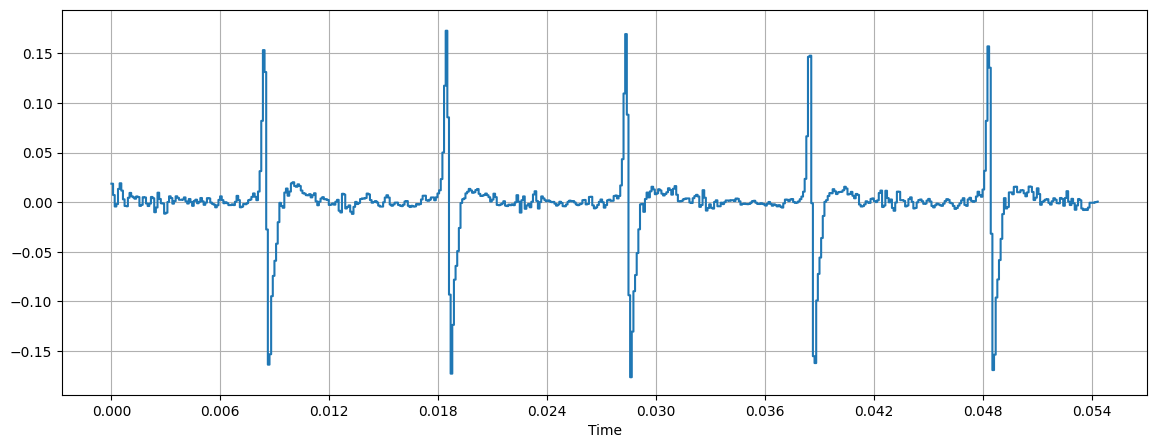

In [ ]:
# Строим осцилограмму (для интервала)
n1 = 1000
n2 = 1600
plt.figure(figsize=(14, 5))
librosa.display.waveshow(data_11_100Hz[n1:n2], sr=sr_11_100Hz)
plt.grid(True)
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 5:</b>
<a id="answer-job5"></a>

Период около 0.0085 у.е. времени

Как говорили раньше: больше размер окна - выше частотное разрешение

Чем больше длина окон, тем больше периодов попадает внутрь

Длина окна должна быть больше или равна периоду повторений импульсов, иначе в одно окно поместится целый период сигнала, и спект будет размазан
</div>